# DSA 210 Project -  Analyzing and Predicting Procrastination Behavior Using Daily Digital Habits


My project is about understanding how my daily habits affect how much I procrastinate. I tracked things like how much I sleep, how long I study, how much I use social media, and how stressed I feel — and then gave myself a procrastination score each day.

The data covers every activity since 03-03-2026. I collected it manually based on my daily routine.

## Setup

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.simplefilter('ignore')

%matplotlib inline

## Loading the Data

In [71]:
from google.colab import files
df = pd.read_csv('procrastination_data.csv', parse_dates=['date'])
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head(10)

Rows: 42, Columns: 9


,date,sleep_hours,study_hours,screen_time,social_media_time,planned_tasks,completed_tasks,stress_level,procrastination_score
0,2026-03-03,6.8,1.7,4.5,2.9,7,5,6,3.9
1,2026-04-03,6.4,2.0,4.5,2.8,6,2,5,7.0
2,2026-05-03,6.9,2.6,4.5,2.0,3,1,5,1.4
3,2026-06-03,7.4,2.1,4.7,2.5,6,3,5,5.3
4,2026-07-03,6.4,1.3,4.4,2.7,5,2,6,5.7
5,2026-08-03,6.4,2.6,6.0,3.7,6,3,7,7.9
6,2026-09-03,7.4,1.7,5.2,3.2,4,3,6,4.1
7,2026-10-03,7.0,2.9,4.3,1.8,4,2,7,1.7
8,2026-11-03,6.2,1.8,4.8,3.2,5,4,6,4.1
9,2026-12-03,6.8,3.7,4.5,2.7,3,1,8,5.1


In [ ]:
df.describe()

,date,sleep_hours,study_hours,screen_time,social_media_time,planned_tasks,completed_tasks,stress_level,procrastination_score
count,42,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,2026-05-15 08:34:17.142857216,6.388095,2.500000,5.002381,2.983333,5.214286,2.714286,6.214286,5.152381
min,2026-01-04 00:00:00,5.300000,1.200000,3.100000,1.200000,3.000000,1.000000,4.000000,1.000000
25%,2026-03-19 06:00:00,6.025000,1.825000,4.500000,2.625000,4.000000,2.000000,5.000000,3.925000
50%,2026-03-29 12:00:00,6.400000,2.700000,4.750000,2.950000,5.500000,3.000000,6.000000,5.000000
75%,2026-07-03 18:00:00,6.700000,2.975000,5.650000,3.550000,6.000000,3.000000,7.000000,6.575000
max,2026-12-04 00:00:00,7.600000,4.000000,7.300000,4.100000,7.000000,5.000000,10.000000,10.000000
std,NaN,0.558396,0.748657,0.846366,0.672787,1.335002,1.174645,1.423423,1.991352


In [73]:
print(f'Bad rows (completed > planned): {(df.completed_tasks > df.planned_tasks).sum()}')
df['task_completion_rate'] = df['completed_tasks'] / df['planned_tasks']
df['is_weekend'] = df['date'].dt.dayofweek >= 5
df[['date', 'planned_tasks', 'completed_tasks', 'task_completion_rate', 'is_weekend']].head()

Bad rows (completed > planned): 0


,date,planned_tasks,completed_tasks,task_completion_rate,is_weekend
0,2026-03-03,7,5,0.714286,False
1,2026-04-03,6,2,0.333333,False
2,2026-05-03,3,1,0.333333,True
3,2026-06-03,6,3,0.500000,False
4,2026-07-03,5,2,0.400000,False


## Basic Statistics

Let me first compute some basic stats manually, like we did in the recitation.

In [74]:
def fmean(data):
    s = 0
    for x in data:
        s += x
    return s / len(data)
def fvar(data):
    mean = fmean(data)
    s = 0
    for x in data:
        s += (x - mean) ** 2
    return s / len(data)
def fstd(data):
    return np.sqrt(fvar(data))
def fmedian(data):
    v = np.sort(data)
    l = len(v)
    return (v[int((l - 0.5) / 2)] + v[int((l + 0.5) / 2)]) / 2
def fcorr(x, y):
    c = np.cov(x, y)
    sx = np.sqrt(c[0][0])
    sy = np.sqrt(c[1][1])
    return c[0][1] / (sx * sy)
proc = df['procrastination_score'].values
print(f'Mean:   {fmean(proc):.2f}')
print(f'Median: {fmedian(proc):.2f}')
print(f'Std:    {fstd(proc):.2f}')
print(f'Var:    {fvar(proc):.2f}')

Mean:   5.15
Median: 5.00
Std:    1.97
Var:    3.87


In [ ]:
features = ['social_media_time', 'sleep_hours', 'study_hours', 'stress_level', 'task_completion_rate']
print('Correlation with procrastination_score:')
for f in features:
    r = fcorr(df[f].values, df['procrastination_score'].values)
    print(f'  {f}: {r:.3f}')

Correlation with procrastination_score:
  social_media_time: 0.378
  sleep_hours: -0.311
  study_hours: -0.065
  stress_level: 0.487
  task_completion_rate: -0.169


### Distributions of Key Variables

Red = mean, Blue = median. When they are far apart, the data is skewed.

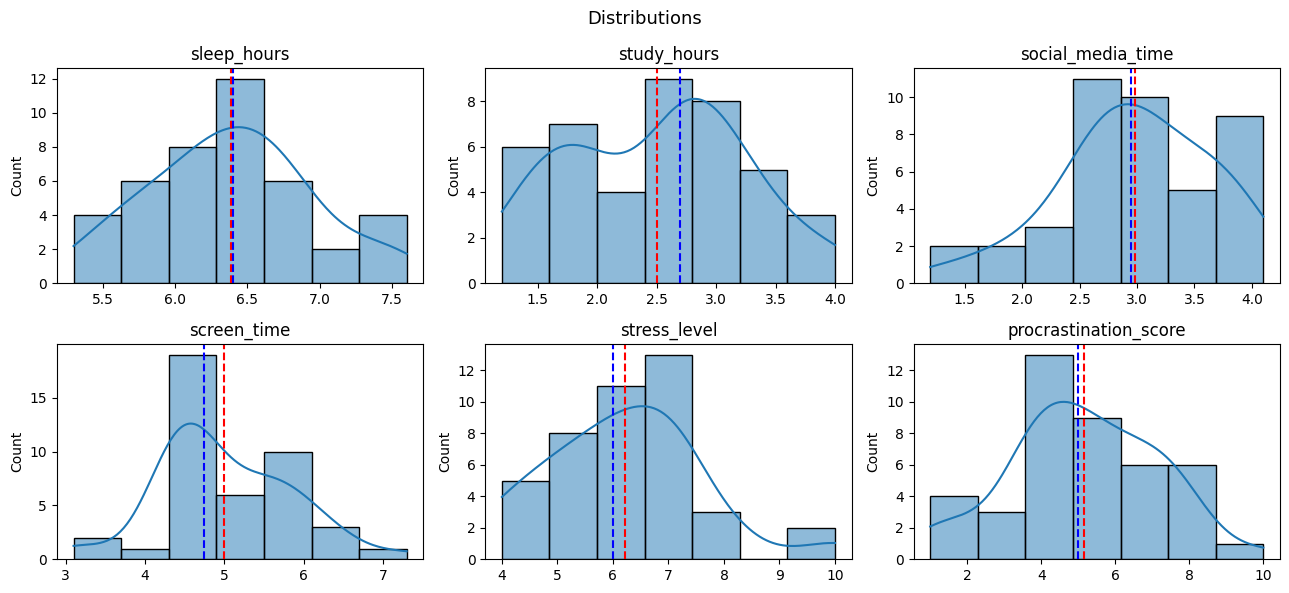

In [ ]:
cols = ['sleep_hours', 'study_hours', 'social_media_time', 'screen_time', 'stress_level', 'procrastination_score']
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.axvline(df[col].mean(), color='red', linestyle='--')
    ax.axvline(df[col].median(), color='blue', linestyle='--')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distributions', fontsize=13)
plt.tight_layout()
plt.show()

### Scatter Plots: What affects procrastination?

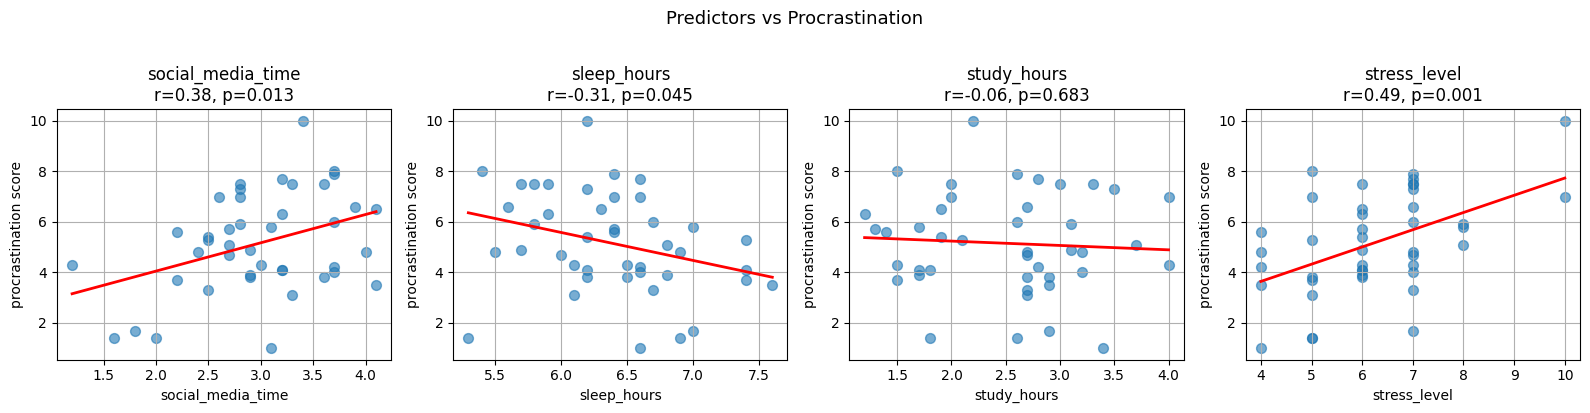

In [ ]:
predictors = ['social_media_time', 'sleep_hours', 'study_hours', 'stress_level']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, predictors):
    ax.scatter(df[col], df['procrastination_score'], alpha=0.6, s=50)
    m, b = np.polyfit(df[col], df['procrastination_score'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=2)
    r = fcorr(df[col].values, df['procrastination_score'].values)
    _, p = stats.pearsonr(df[col], df['procrastination_score'])
    ax.set_title(f'{col}\nr={r:.2f}, p={p:.3f}')
    ax.set_xlabel(col)
    ax.set_ylabel('procrastination score')
    ax.grid()
plt.suptitle('Predictors vs Procrastination', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Hypothesis Testing

Now I'll test some hypotheses about my procrastination behavior. For each one I state the null hypothesis (H0) and the alternative hypothesis (H1), run the test, and check the p-value.

### H1: More social media → more procrastination?

- **H0**: Social media time has no correlation with procrastination score.
- **H1**: More social media time means higher procrastination.
- **Test**: Pearson correlation (one-tailed), α = 0.05

In [ ]:
r, p_two = stats.pearsonr(df['social_media_time'], df['procrastination_score'])
p_one = p_two / 2
print(f'r = {r:.3f}')
print(f'p-value (one-tailed) = {p_one:.4f}')
if p_one < 0.05 and r > 0:
    print('Result: Reject H0 – social media is positively correlated with procrastination')
else:
    print('Result: Fail to reject H0')

r = 0.378
p-value (one-tailed) = 0.0067
Result: Reject H0 – social media is positively correlated with procrastination


### H2: Less sleep → more procrastination?

- **H0**: Sleep hours have no correlation with procrastination score.
- **H1**: Less sleep means higher procrastination.
- **Test**: Pearson correlation (one-tailed), α = 0.05

In [ ]:
r, p_two = stats.pearsonr(df['sleep_hours'], df['procrastination_score'])
p_one = p_two / 2
print(f'r = {r:.3f}')
print(f'p-value (one-tailed) = {p_one:.4f}')
if p_one < 0.05 and r < 0:
    print('Result: Reject H0 – less sleep is correlated with more procrastination')
else:
    print('Result: Fail to reject H0')

r = -0.311
p-value (one-tailed) = 0.0225
Result: Reject H0 – less sleep is correlated with more procrastination


### H3: Do I procrastinate more on weekends?

- **H0**: My procrastination score is the same on weekdays and weekends.
- **H1**: I procrastinate more on weekends.
- **Test**: Independent samples t-test (one-tailed), α = 0.05

In [ ]:
weekday = df[df['is_weekend'] == False]['procrastination_score']
weekend = df[df['is_weekend'] == True]['procrastination_score']
t_stat, p_two = stats.ttest_ind(weekend, weekday)
p_one = p_two / 2
print(f'Weekday mean = {weekday.mean():.2f}')
print(f'Weekend mean = {weekend.mean():.2f}')
print(f't = {t_stat:.3f}')
print(f'p-value (one-tailed) = {p_one:.4f}')
if p_one < 0.05 and t_stat > 0:
    print('Result: Reject H0 – weekends have significantly higher procrastination')
else:
    print('Result: Fail to reject H0')

Weekday mean = 5.13
Weekend mean = 5.22
t = 0.131
p-value (one-tailed) = 0.4483
Result: Fail to reject H0


### H4: Completing more tasks → less procrastination?

- **H0**: Task completion rate has no relationship with procrastination score.
- **H1**: Completing more tasks is linked to lower procrastination.
- **Test**: Spearman correlation (one-tailed), α = 0.05

I used Spearman here instead of Pearson because this relationship might not be perfectly linear.

In [ ]:
r_sp, p_two = stats.spearmanr(df['task_completion_rate'], df['procrastination_score'])
p_one = p_two / 2
print(f'Spearman r = {r_sp:.3f}')
print(f'p-value (one-tailed) = {p_one:.4f}')
if p_one < 0.05 and r_sp < 0:
    print('Result: Reject H0 – completing more tasks is linked to less procrastination')
else:
    print('Result: Fail to reject H0')

Spearman r = -0.205
p-value (one-tailed) = 0.0966
Result: Fail to reject H0
